# 베이스라인 모델 비교 (`01_Baseline_Models`)

25일 시점 재학생(`model_df_clean`, 27,654행)을 대상으로 **25일 이후 중도 이탈**을 예측하는 베이스라인
모델을 비교하고 챔피언 모델을 선정한다. `work_process/reports/04_next_steps.md` P4에 해당한다.

```
02_Integrated_Table → 03_Landmark25_EDA → 04_Missing_Outlier → 05_Collinearity_Recheck → [03_Modeling/01_Baseline_Models]
```

> **2026-09-13 개정**: 파이프라인 검증(`work_process/reports/07_pipeline_audit_before_final.md`)과 25일 코호트 EDA
> (`03_Landmark25_EDA`)의 발견을 반영해 다시 구성했다. 첫 버전 대비 바뀐 점은 다음과 같다.
>
> - 통합 정본의 평가 기회·이월 정의 변경 → 피처 20개(`n_banked_25` 추가)
> - **학기 단위 검증**(한 학기를 통째로 빼는 검증)을 보조 지표로 추가 — 기존 CV가 학기 간 편차를 가렸음
> - **과목·학기 내 상대 활동 피처**를 사전에 정한 규칙으로 비교해 채택 여부 결정
> - **확률 보정** — 클래스 가중치 때문에 확률이 실제 이탈률보다 크게 나왔음
> - **과목별 성능표**를 기본 보고로, 전역 임계값과 **과목별 상위 k%** 기준을 함께 비교

진행 순서:

1. 데이터·피처 명세 로드와 계약 검증, 상대 피처 파생
2. `2014J` holdout 분리
3. 교차검증 분할 고정 (`StratifiedGroupKFold` + 학기 단위)
4. 모델별 `Pipeline` 정의
5. 튜닝·비교 (주 지표 PR-AUC)
6. 학기 단위 검증
7. 상대 피처 비교와 최종 피처셋 결정
8. OOF 상세 비교와 과목별 성능
9. 챔피언 선정
10. 확률 보정
11. 임계값 후보 비교
12. 챔피언 `2014J` holdout 평가
13. 결과 저장
14. 결론

선행 문서:

- `work_process/decisions/preprocessing/0912_03_collinearity_final_features.md` (피처, 9절 모델별 전처리, 10절 검증 분할)
- `work_process/decisions/preprocessing/0913_01_assessment_opportunity_banked.md` (평가 기회·이월 정의)
- `Notebooks/02_Window_Integration/03_Landmark25_EDA.ipynb` 14절 (모델링 반영 사항)

## 1. 환경 설정 및 데이터 로드

In [1]:
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
N_JOBS = 4  # 메모리 여유(16GB 중 약 6GB)를 고려해 병렬 작업 수를 제한
MODEL_COLORS = {'Logistic': '#2a78d6', 'RandomForest': '#eb6834', 'XGBoost': '#1baf7a'}


def show(frame, formats=None):
    # jinja2 없이 열별 서식을 적용해 표시한다
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()

DATA_DIR = PROJECT_ROOT / 'CSV_files' / '통합 버전'
SPEC_PATH = DATA_DIR / 'feature_spec_n25.json'
CLEAN_PATH = DATA_DIR / 'model_df_clean_n25.csv'
OUTPUT_DIR = PROJECT_ROOT / 'CSV_files' / '모델링'

with open(SPEC_PATH, encoding='utf-8') as f:
    spec = json.load(f)
model_df_clean = pd.read_csv(CLEAN_PATH)

print('Python      :', platform.python_version())
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('xgboost     :', xgboost.__version__)
print('데이터 shape:', model_df_clean.shape)
print('피처 정의 버전:', spec.get('definition_version'))

Python      : 3.14.5
pandas      : 3.0.3
scikit-learn: 1.9.0
xgboost     : 3.3.0
데이터 shape: (27654, 30)
피처 정의 버전: 0913_01 — 평가 기회 weight 조건 없음, 이월 평가는 학생별 기회에서 제외(n_banked_25)


### 1.1 피처 명세 적용과 데이터 계약 검증

피처 목록은 노트북에서 다시 정의하지 않고 **`feature_spec_n25.json`만 읽는다**(`05_Collinearity_Recheck`가 생성).

검증 항목: 행 수·양성 수 명세 일치, 그레인 유일, 누수·제외 컬럼 미포함, NaN 보유 피처 일치, 평가 기회·이월 정의 버전

In [2]:
TARGET = spec['target']
GROUP_COL = spec['group_col']
HOLDOUT_KEY = spec['holdout_key']
BASE_NUM = spec['numeric_features']
CAT_FEATURES = spec['categorical_features']
GRAIN = ['id_student', 'code_module', 'code_presentation']

df = model_df_clean.copy()
df['presentation_period'] = df['code_presentation'].str[-1]
df[TARGET] = df[TARGET].astype(int)

assert str(spec.get('definition_version', '')).startswith('0913_01'), '평가 기회·이월 정의 변경 전 명세'
assert len(df) == spec['n_rows'] and df[TARGET].sum() == spec['n_positive']
assert not df.duplicated(GRAIN).any()
assert len(BASE_NUM) + len(CAT_FEATURES) == 20
forbidden = set(spec['excluded']) | {TARGET}
assert not forbidden & set(BASE_NUM + CAT_FEATURES)
nan_cols = sorted(df[BASE_NUM + CAT_FEATURES].columns[df[BASE_NUM + CAT_FEATURES].isna().any()])
assert nan_cols == sorted(spec['nan_features'])

print(f'기본 피처 {len(BASE_NUM) + len(CAT_FEATURES)}개 (수치형 {len(BASE_NUM)} + 범주형 {len(CAT_FEATURES)})')
print(f'행 {len(df):,} / 양성 {df[TARGET].sum():,} ({df[TARGET].mean():.2%})')

기본 피처 20개 (수치형 12 + 범주형 8)
행 27,654 / 양성 5,246 (18.97%)


### 1.2 과목·학기 내 상대 활동 피처 파생 (비교 후보)

`03_Landmark25_EDA` 8절에서 **같은 절대 클릭 수가 과목마다 다른 위험을 뜻하고**, 과목·학기 안의 상대 위치로 보면
패턴이 일관됨을 확인했다(단일 AUC 0.563 → 0.604). EDA 단계에서 "모델링에서 비교한 뒤 결정한다"로 정했으므로 후보로만 만든다.

- 대상: `total_click_25`, `active_days_25`, `distinct_resources_25` (11절 SMD에서 학기 간 이동이 컸던 자원 수 포함)
- 정의: 같은 `(code_module, code_presentation)` 재학생 안에서의 백분위 순위(0–1]
- **누수 점검**: 타깃을 쓰지 않고, 25일 시점에 그 학기 재학생 전체의 25일 데이터로 계산 가능하다. 학기 안에서만 계산하므로
  개발 학기와 holdout 학기 값이 서로 섞이지 않는다.

In [3]:
REL_SOURCE = ['total_click_25', 'active_days_25', 'distinct_resources_25']
REL_FEATURES = [c + '_pct' for c in REL_SOURCE]
term_group = df.groupby(['code_module', 'code_presentation'])
for c in REL_SOURCE:
    df[c + '_pct'] = term_group[c].rank(pct=True, method='average')

assert df[REL_FEATURES].notna().all().all() and (df[REL_FEATURES] > 0).all().all() and (df[REL_FEATURES] <= 1).all().all()
# 같은 과목·학기 안에서 절대값 순서와 백분위 순서가 일치하는지
check = df.groupby(['code_module', 'code_presentation']).apply(
    lambda g: all(g[c].corr(g[c + '_pct'], method='spearman') > 0.99 for c in REL_SOURCE if g[c].nunique() > 1),
    include_groups=False)
assert check.all()
show(df.groupby('code_module')[REL_SOURCE + REL_FEATURES].median(), {c: '{:.2f}' for c in REL_FEATURES})

,total_click_25,active_days_25,distinct_resources_25,total_click_25_pct,active_days_25_pct,distinct_resources_25_pct
code_module,,,,,,
AAA,262.0,13.0,20.0,0.50,0.49,0.50
BBB,88.0,6.0,13.0,0.50,0.50,0.49
CCC,196.0,9.0,17.0,0.50,0.52,0.49
DDD,155.0,11.0,25.0,0.50,0.48,0.50
EEE,268.0,10.0,16.0,0.50,0.49,0.51
FFF,371.5,13.0,37.0,0.50,0.49,0.50
GGG,31.0,3.0,7.0,0.50,0.49,0.47


## 2. `2014J` holdout 분리

마지막 학기 `2014J`는 **최종 평가 전용**이다. 튜닝·피처셋 결정·보정·임계값 선택은 모두 나머지 3개 학기(개발 세트)에서만
하고, holdout은 12절에서 챔피언에 **한 번만** 쓴다.

In [4]:
HOLDOUT_TERM = '2014J'
is_holdout = df[HOLDOUT_KEY] == HOLDOUT_TERM
dev_df = df.loc[~is_holdout].reset_index(drop=True)
hold_df = df.loc[is_holdout].reset_index(drop=True)
y_dev, groups_dev = dev_df[TARGET], dev_df[GROUP_COL]
y_hold = hold_df[TARGET]

assert len(hold_df) == 9150 and len(dev_df) + len(hold_df) == len(df)

split_summary = pd.DataFrame({
    '행 수': [len(dev_df), len(hold_df)],
    '양성 수': [y_dev.sum(), y_hold.sum()],
    '이탈률': [y_dev.mean(), y_hold.mean()],
    '학생 수': [dev_df[GROUP_COL].nunique(), hold_df[GROUP_COL].nunique()],
}, index=['개발(2013B·2013J·2014B)', 'holdout(2014J)'])
show(split_summary, {'이탈률': '{:.2%}', '행 수': '{:,}', '양성 수': '{:,}', '학생 수': '{:,}'})
overlap = set(dev_df[GROUP_COL]) & set(hold_df[GROUP_COL])
print(f'개발·holdout 양쪽에 등장하는 학생: {len(overlap):,}명 (holdout 행의 {hold_df[GROUP_COL].isin(overlap).mean():.2%})')

,행 수,양성 수,이탈률,학생 수
개발(2013B·2013J·2014B),"18,504","3,526",19.06%,"17,407"
holdout(2014J),"9,150","1,720",18.80%,"8,799"


개발·holdout 양쪽에 등장하는 학생: 1,259명 (holdout 행의 14.02%)


개발·holdout에 동시에 등장하는 학생은 제거하지 않는다. "과거 학기로 학습해 다음 학기를 예측"하는 시간 분할이고,
실제 배포에서도 재수강생이 새 학기에 다시 등록한다. 입력 피처에는 학생 ID나 과거 결과가 없다(이력은 `num_of_prev_attempts`·`n_banked_25`뿐).

## 3. 교차검증 분할 고정

두 가지 분할을 **한 번만 만들어 리스트로 고정**하고 모든 모델에 재사용한다.

| 분할 | 구성 | 역할 |
|---|---|---|
| `CV_SPLITS` | `StratifiedGroupKFold(5, shuffle=True, random_state=42)`, `groups=id_student` | **튜닝·모델 비교의 주 지표** |
| `TERM_SPLITS` | 개발 학기 하나를 통째로 검증, 나머지로 학습 | **학기가 바뀔 때 성능이 얼마나 흔들리는지** 보는 보조 지표 |

`CV_SPLITS`는 모든 fold에 세 학기가 섞여 학기 간 차이를 가린다(감사 보고서 2.2절). `TERM_SPLITS`는 fold 수가 적어 튜닝에는 쓰지 않고,
모델 선택의 안정성 판단과 피처셋 비교에만 쓴다. 학기 단위 분할에서는 같은 학생이 다른 학기에 학습·검증으로 나뉠 수 있는데, 이는 holdout과
같은 시간 분할의 현실 조건이다.

**학습에 없는 범주 처리 (첫 실행에서 발견해 수정)**: 개발 학기가 3개뿐이라 한 학기를 빼면 **학습 쪽에 없는 범주**가 생긴다.
AAA는 2013J에만, CCC는 2014B에만 있고, J학기는 2013J 하나뿐이다. 이런 범주는 원-핫에서 전부 0으로 인코딩되어 점수가 인위적으로
낮아진다. 실제 holdout(2014J)은 모든 과목·개강 시기가 학습에 있으므로 이 문제가 없다. 따라서 **검증 행 중 모든 범주형 값이 학습 쪽에
존재하는 행만 평가**하고, 남는 행이 없는 fold는 뺀다. 2013J를 검증하는 fold는 전 행이 학습에 없는 `presentation_period = J`라 제외된다.

In [5]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_SPLITS = list(sgkf.split(dev_df, y_dev, groups=groups_dev))
covered = np.zeros(len(dev_df), dtype=int)
fold_rows = []
for i, (tr, va) in enumerate(CV_SPLITS):
    assert not set(groups_dev.iloc[tr]) & set(groups_dev.iloc[va])
    covered[va] += 1
    fold_rows.append({'fold': i, '학습 행': len(tr), '검증 행': len(va), '검증 이탈률': y_dev.iloc[va].mean()})
assert (covered == 1).all()
show(pd.DataFrame(fold_rows), {'검증 이탈률': '{:.2%}'})

DEV_TERMS = sorted(dev_df[HOLDOUT_KEY].unique())
TERM_SPLITS, TERM_NAMES, term_rows = [], [], []
for t in DEV_TERMS:
    tr = np.where(dev_df[HOLDOUT_KEY] != t)[0]
    va_all = np.where(dev_df[HOLDOUT_KEY] == t)[0]
    seen = np.ones(len(va_all), dtype=bool)
    unseen = {}
    for c in CAT_FEATURES:
        vals = dev_df.loc[va_all, c]
        miss = ~vals.isin(set(dev_df.loc[tr, c])).to_numpy()
        if miss.any():
            unseen[c] = sorted(vals[miss].unique())
        seen &= ~miss
    va = va_all[seen]
    used = len(va) > 0 and y_dev.iloc[va].nunique() == 2
    if used:
        TERM_SPLITS.append((tr, va))
        TERM_NAMES.append(t)
    term_rows.append({'검증 학기': t, '학습 행': len(tr), '검증 행(전체)': len(va_all), '검증 행(평가)': len(va),
                      '학습에 없는 범주': str(unseen) if unseen else '-', '사용': '예' if used else '아니오(평가 가능 행 없음)',
                      '평가 행 이탈률': y_dev.iloc[va].mean() if len(va) else np.nan})
    # 평가 행에는 학습에 없는 범주가 남지 않아야 한다
    for c in CAT_FEATURES:
        assert dev_df.loc[va, c].isin(set(dev_df.loc[tr, c])).all()
show(pd.DataFrame(term_rows), {'평가 행 이탈률': '{:.2%}'})
print('사용하는 학기 단위 fold:', TERM_NAMES)

,fold,학습 행,검증 행,검증 이탈률
0,0,14802,3702,19.04%
1,1,14802,3702,19.07%
2,2,14804,3700,19.05%
3,3,14804,3700,19.05%
4,4,14804,3700,19.05%


,검증 학기,학습 행,검증 행(전체),검증 행(평가),학습에 없는 범주,사용,평가 행 이탈률
0,2013B,14230,4274,4274,-,예,22.11%
1,2013J,10812,7692,0,"{'code_module': ['AAA'], 'presentation_period'...",아니오(평가 가능 행 없음),
2,2014B,11966,6538,5018,{'code_module': ['CCC']},예,17.36%


사용하는 학기 단위 fold: ['2013B', '2014B']


## 4. 모델별 `Pipeline` 정의

결정 문서 `0912_03` 9절을 구현한다. 전처리는 모두 `Pipeline` 안에 있어 각 fold의 학습 부분에서만 `fit`된다.

| 처리 | Logistic | RandomForest | XGBoost |
|---|---|---|---|
| 수치형 결측 | `SimpleImputer(median, add_indicator=True)` | 동일 | 대치 안 함 (NaN 유지) |
| 수치형 스케일링 | `RobustScaler` | 없음 | 없음 |
| 범주형 | `OneHotEncoder(drop='first')` | `OneHotEncoder` | `OneHotEncoder` (밀집 출력) |
| 불균형 | `class_weight='balanced'` | `class_weight='balanced'` | `scale_pos_weight` |

- **XGBoost 입력은 밀집 행렬로 강제**한다(`sparse_output=False`, `sparse_threshold=0`). XGBoost는 희소 행렬에서 저장되지 않은 0을
  결측으로 취급하므로, 원-핫 0이나 `total_click_25 = 0`이 NaN처럼 학습되는 것을 막는다.
- 파이프라인은 수치형 피처 목록을 인자로 받는다. 7절에서 상대 피처를 추가한 변형을 같은 모델 설정으로 만들기 위해서다.
- 탐색 격자는 첫 버전에서 경계값이 걸린 뒤 넓힌 격자를 그대로 쓴다.

In [6]:
SCALE_POS_WEIGHT = (y_dev == 0).sum() / (y_dev == 1).sum()


def make_pipeline(name, num_features):
    if name == 'Dummy':
        return Pipeline([('model', DummyClassifier(strategy='prior'))])
    if name == 'Logistic':
        prep = ColumnTransformer([
            ('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)), ('scale', RobustScaler())]), num_features),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_FEATURES),
        ])
        model = LogisticRegression(class_weight='balanced', max_iter=5000)
    elif name == 'RandomForest':
        prep = ColumnTransformer([
            ('num', SimpleImputer(strategy='median', add_indicator=True), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
        ])
        model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1)
    elif name == 'XGBoost':
        prep = ColumnTransformer([
            ('num', 'passthrough', num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
        ], sparse_threshold=0)
        model = XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SCALE_POS_WEIGHT,
                              tree_method='hist', eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=1)
    else:
        raise ValueError(name)
    return Pipeline([('prep', prep), ('model', model)])


PARAM_GRIDS = {
    'Dummy': {},
    'Logistic': {'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'RandomForest': {'model__max_depth': [None, 12], 'model__min_samples_leaf': [10, 30, 60], 'model__max_features': ['sqrt', 0.5, 0.8]},
    'XGBoost': {'model__max_depth': [2, 3, 5], 'model__learning_rate': [0.01, 0.03, 0.1], 'model__min_child_weight': [1, 10, 30]},
}
MODEL_NAMES = list(PARAM_GRIDS)
LEARNERS = ['Logistic', 'RandomForest', 'XGBoost']

_x = make_pipeline('XGBoost', BASE_NUM).named_steps['prep'].fit_transform(dev_df)
assert isinstance(_x, np.ndarray) and np.isnan(_x).any()
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.3f}')
print('XGBoost 전처리 출력:', type(_x).__name__, _x.shape, f'/ NaN 셀 {np.isnan(_x).sum():,}개 유지')

scale_pos_weight = 4.248
XGBoost 전처리 출력: ndarray (18504, 57) / NaN 셀 11,482개 유지


## 5. 튜닝과 교차검증 비교 (기본 피처 20개, 주 지표 PR-AUC)

`(이름, 파이프라인, 탐색 공간)`을 **동일 루프**로 순회한다. 모든 모델이 같은 `CV_SPLITS`를 쓰고 PR-AUC(`average_precision`) 기준으로
최적 조합을 고른다. 이탈률 약 19%의 불균형 문제라 양성 예측의 질을 직접 보는 PR-AUC를 주 지표로 둔다. Dummy의 PR-AUC가 하한선이다.

> 같은 fold로 튜닝과 점수 산출을 함께 하므로 CV 최고 점수는 약간 낙관적이다. 편향 없는 성능은 12절 holdout에서 확인한다.

In [7]:
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'}
search_results = {}
for name in MODEL_NAMES:
    t0 = time.perf_counter()
    search = GridSearchCV(make_pipeline(name, BASE_NUM), PARAM_GRIDS[name], scoring=SCORING, refit='pr_auc', cv=CV_SPLITS, n_jobs=N_JOBS)
    search.fit(dev_df[BASE_NUM + CAT_FEATURES], y_dev)
    search_results[name] = search
    i, cvr = search.best_index_, search.cv_results_
    print(f'{name:<12} 조합 {len(cvr["params"]):>2}개 | PR-AUC {cvr["mean_test_pr_auc"][i]:.4f} ± {cvr["std_test_pr_auc"][i]:.4f} | '
          f'ROC-AUC {cvr["mean_test_roc_auc"][i]:.4f} | {time.perf_counter() - t0:.1f}s | best {search.best_params_}')

BEST_PARAMS = {name: s.best_params_ for name, s in search_results.items()}
cv_table = pd.DataFrame([{
    'model': name,
    'cv_pr_auc_mean': s.cv_results_['mean_test_pr_auc'][s.best_index_],
    'cv_pr_auc_std': s.cv_results_['std_test_pr_auc'][s.best_index_],
    'cv_roc_auc_mean': s.cv_results_['mean_test_roc_auc'][s.best_index_],
    'best_params': json.dumps(s.best_params_, default=str),
} for name, s in search_results.items()]).set_index('model')
show(cv_table, {c: '{:.4f}' for c in cv_table.columns if 'auc' in c})

Dummy        조합  1개 | PR-AUC 0.1906 ± 0.0001 | ROC-AUC 0.5000 | 7.3s | best {}


Logistic     조합  5개 | PR-AUC 0.4002 ± 0.0147 | ROC-AUC 0.7246 | 8.0s | best {'model__C': 100.0}


RandomForest 조합 18개 | PR-AUC 0.4061 ± 0.0153 | ROC-AUC 0.7269 | 523.2s | best {'model__max_depth': 12, 'model__max_features': 0.5, 'model__min_samples_leaf': 30}


XGBoost      조합 27개 | PR-AUC 0.4056 ± 0.0134 | ROC-AUC 0.7281 | 107.6s | best {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 30}


,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,best_params
model,,,,
Dummy,0.1906,0.0001,0.5000,{}
Logistic,0.4002,0.0147,0.7246,"{""model__C"": 100.0}"
RandomForest,0.4061,0.0153,0.7269,"{""model__max_depth"": 12, ""model__max_features""..."
XGBoost,0.4056,0.0134,0.7281,"{""model__learning_rate"": 0.01, ""model__max_dep..."


### 5.1 탐색 공간 경계 점검

최적값이 격자 끝에 걸렸는데 인접 조합과 차이가 크면 범위를 넓혀야 한다. 차이가 작으면(평탄 구간) 넓혀도 얻을 것이 없다.

In [8]:
for name in LEARNERS:
    cvr = pd.DataFrame(search_results[name].cv_results_)
    params = [c for c in cvr.columns if c.startswith('param_model__')]
    view = cvr[params + ['mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc']].sort_values('rank_test_pr_auc')
    view = view.rename(columns=lambda c: c.replace('param_model__', ''))
    print(f'■ {name} — 1위와 5위 차이 {view["mean_test_pr_auc"].iloc[0] - view["mean_test_pr_auc"].iloc[min(4, len(view) - 1)]:.4f}')
    show(view.head(5), {'mean_test_pr_auc': '{:.4f}', 'std_test_pr_auc': '{:.4f}'})

■ Logistic — 1위와 5위 차이 0.0038


,C,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
4,100.00,0.4002,0.0147,1
3,10.00,0.4000,0.0145,2
2,1.00,0.3994,0.0144,3
1,0.10,0.3993,0.0144,4
0,0.01,0.3964,0.0146,5


■ RandomForest — 1위와 5위 차이 0.0032


,max_depth,max_features,min_samples_leaf,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
13,12,0.5,30,0.4061,0.0153,1
3,None,0.5,10,0.4057,0.0165,2
12,12,0.5,10,0.4056,0.0152,3
4,None,0.5,30,0.4055,0.0149,4
7,None,0.8,30,0.4029,0.0155,5


■ XGBoost — 1위와 5위 차이 0.0027


,learning_rate,max_depth,min_child_weight,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
8,0.01,5,30,0.4056,0.0134,1
7,0.01,5,10,0.4046,0.0129,2
14,0.03,3,30,0.4045,0.0149,3
17,0.03,5,30,0.4042,0.0147,4
13,0.03,3,10,0.4029,0.0122,5


## 6. 학기 단위 검증

**왜 보는가**: `CV_SPLITS` 점수는 학기가 섞인 상태의 성능이다. 실제 사용은 "지난 학기들로 학습 → 새 학기 예측"이므로, 개발 학기
하나를 통째로 빼고 검증했을 때 성능이 얼마나 흔들리는지 본다. 튜닝된 최적 파라미터를 그대로 쓴다.

**판단 기준**: 평균이 높을수록 좋고, **학기 간 최솟값이 낮거나 흔들림(최대−최소)이 큰 모델은 새 학기에 불안정**하다.

In [9]:
def fit_predict(name, num_features, tr, va, frame=dev_df, y=y_dev):
    pipe = make_pipeline(name, num_features).set_params(**BEST_PARAMS[name])
    if name in ('RandomForest', 'XGBoost'):
        pipe.set_params(model__n_jobs=N_JOBS)  # 단일 적합은 모델 내부 병렬화 (GridSearch에서는 바깥 병렬화)
    pipe.fit(frame.loc[tr, num_features + CAT_FEATURES], y.iloc[tr])
    return pipe.predict_proba(frame.loc[va, num_features + CAT_FEATURES])[:, 1]


def split_scores(name, num_features, splits):
    return [average_precision_score(y_dev.iloc[va], fit_predict(name, num_features, tr, va)) for tr, va in splits]


term_rows = []
for name in LEARNERS:
    s = split_scores(name, BASE_NUM, TERM_SPLITS)
    term_rows.append({'model': name, **{f'검증 {t}': v for t, v in zip(TERM_NAMES, s)},
                      '학기 단위 평균': np.mean(s), '학기 단위 최소': np.min(s), '흔들림(최대-최소)': np.max(s) - np.min(s),
                      'CV 평균(5절)': cv_table.loc[name, 'cv_pr_auc_mean']})
term_table = pd.DataFrame(term_rows).set_index('model')
term_table['CV − 학기 단위'] = term_table['CV 평균(5절)'] - term_table['학기 단위 평균']
show(term_table, {c: '{:.4f}' for c in term_table.columns})
print('평가 행 이탈률:', {t: f'{y_dev.iloc[va].mean():.1%}' for t, (_, va) in zip(TERM_NAMES, TERM_SPLITS)})

,검증 2013B,검증 2014B,학기 단위 평균,학기 단위 최소,흔들림(최대-최소),CV 평균(5절),CV − 학기 단위
model,,,,,,,
Logistic,0.3106,0.3256,0.3181,0.3106,0.0151,0.4002,0.0820
RandomForest,0.3905,0.2955,0.3430,0.2955,0.0949,0.4061,0.0631
XGBoost,0.3973,0.3236,0.3604,0.3236,0.0737,0.4056,0.0452


평가 행 이탈률: {'2013B': '22.1%', '2014B': '17.4%'}


**해석**

- **2013J를 검증하는 fold는 제외됐다.** 학습 학기(2013B·2014B)에 J학기가 없어 전 행의 `presentation_period`가 학습에 없는 범주이기 때문이다.
  2014B fold는 학습에 없는 CCC 1,520행을 빼고 5,018행으로 평가했다. 결과적으로 학기 단위 검증은 **2개 fold**다.
- **학기가 바뀌면 모든 모델의 PR-AUC가 크게 떨어진다.** Logistic −0.082, RandomForest −0.063, XGBoost −0.045다.
  단 학기 단위 fold는 학습 행이 더 적고(11,966–14,230행) 검증 학기 이탈률도 달라(22.1% / 17.4%), **절대값보다 모델 간 상대 비교로 본다.**
- **순위가 CV와 다르다.** CV에서는 RandomForest ≈ XGBoost > Logistic이었지만, 학기 단위에서는 **XGBoost(0.360) > RandomForest(0.343) > Logistic(0.318)**이다.
  - XGBoost: 평균이 가장 높고 최솟값(0.324)도 가장 높다.
  - RandomForest: 2013B 0.391 → 2014B 0.296으로 **흔들림이 가장 크다(0.095).**
  - Logistic: 두 학기 모두 낮지만 흔들림은 가장 작다(0.015).

## 7. 과목·학기 내 상대 피처 비교와 최종 피처셋 결정

**사전 채택 규칙(실행 전에 고정)**: 기본 20개에 상대 피처 3개를 더한 23개 피처셋을 같은 최적 파라미터로 평가한다.
**세 학습 모델(Logistic·RandomForest·XGBoost)의 평균 PR-AUC 변화가 `CV_SPLITS`와 `TERM_SPLITS` 양쪽에서 모두 0보다 크면 채택**하고,
어느 한쪽이라도 0 이하이면 기본 피처셋을 유지한다.

- 두 검증을 모두 요구하는 이유: 상대 피처의 목적이 "과목·학기가 달라도 같은 의미"이므로, 학기가 섞인 CV에서만 좋아지는 것은 목적에 맞지 않는다.
- 파라미터는 5절 최적값으로 고정한다(피처셋마다 다시 튜닝하면 비교에 튜닝 효과가 섞인다). holdout은 쓰지 않는다.

In [10]:
REL_NUM = BASE_NUM + REL_FEATURES
rel_rows = []
for name in LEARNERS:
    base_cv = cv_table.loc[name, 'cv_pr_auc_mean']
    rel_cv = np.mean(split_scores(name, REL_NUM, CV_SPLITS))
    base_term = term_table.loc[name, '학기 단위 평균']
    rel_term = np.mean(split_scores(name, REL_NUM, TERM_SPLITS))
    rel_rows.append({'model': name, 'CV 기본': base_cv, 'CV +상대': rel_cv, 'CV 변화': rel_cv - base_cv,
                     '학기 단위 기본': base_term, '학기 단위 +상대': rel_term, '학기 단위 변화': rel_term - base_term})
rel_table = pd.DataFrame(rel_rows).set_index('model')
show(rel_table, {c: '{:+.4f}' if '변화' in c else '{:.4f}' for c in rel_table.columns})

mean_cv_delta, mean_term_delta = rel_table['CV 변화'].mean(), rel_table['학기 단위 변화'].mean()
ADOPT_REL = bool(mean_cv_delta > 0 and mean_term_delta > 0)
FINAL_NUM = REL_NUM if ADOPT_REL else BASE_NUM
FINAL_FEATURES = FINAL_NUM + CAT_FEATURES
print(f'평균 변화 — CV {mean_cv_delta:+.4f}, 학기 단위 {mean_term_delta:+.4f} → 상대 피처 {"채택" if ADOPT_REL else "미채택"}')
print(f'최종 피처 {len(FINAL_FEATURES)}개')

,CV 기본,CV +상대,CV 변화,학기 단위 기본,학기 단위 +상대,학기 단위 변화
model,,,,,,
Logistic,0.4002,0.3999,-0.0002,0.3181,0.3178,-0.0003
RandomForest,0.4061,0.4065,+0.0003,0.3430,0.3415,-0.0015
XGBoost,0.4056,0.4069,+0.0013,0.3604,0.3578,-0.0026


평균 변화 — CV +0.0005, 학기 단위 -0.0015 → 상대 피처 미채택
최종 피처 20개


**해석**

- 상대 피처를 더하면 CV에서는 평균 **+0.0005**(XGBoost +0.0013)로 조금 오르지만, 학기 단위에서는 **세 모델 모두 떨어진다**(평균 −0.0015, XGBoost −0.0026).
- 사전 규칙(두 검증 모두 개선)을 충족하지 못해 **상대 피처는 채택하지 않는다.** 최종 피처는 기본 20개다.
- EDA에서 단일 피처로는 상대 기준이 더 강했다(AUC 0.563 → 0.604). 그런데도 모델에서 이득이 없는 이유는 두 가지로 보인다.
  1. 모델에 이미 `code_module`이 있어, 트리 모델은 "과목 × 절대 활동량" 상호작용을 스스로 학습한다.
  2. 백분위로 바꾸면 절대 규모 정보가 사라진다(예: 학기 전체가 활동이 적은 GGG 2013J).
- 상대 기준은 모델 입력보다 **해석·개입 설명**("같은 과목 학생 중 하위 25%")에 더 쓸모가 있다.

## 8. OOF 상세 비교와 과목별 성능 (최종 피처셋)

각 모델의 최적 파라미터와 최종 피처셋으로 같은 `CV_SPLITS`에 out-of-fold 확률을 만든다. 모든 개발 행이 자기를 학습하지 않은
모델로 한 번씩 예측되므로 지표를 편향 없이 비교할 수 있다.

- 모델마다 확률 스케일이 달라 **같은 규칙(F1 최대)**으로 각자 임계값을 잡아 비교한다.
- **과목별 성능표**를 기본으로 보고한다(`03_Landmark25_EDA` 14절). EEE·GGG는 25일 안에 평가가 없는 과목이라 따로 표시한다.

In [11]:
NO_ASSESSMENT_MODULES = sorted(dev_df.groupby('code_module')['n_opportunity_25'].max().loc[lambda s: s == 0].index)
MODULES = sorted(df['code_module'].unique())

oof_proba = {'Dummy': np.full(len(dev_df), y_dev.mean())}
fold_pr = {}
for name in LEARNERS:
    p = np.zeros(len(dev_df))
    for tr, va in CV_SPLITS:
        p[va] = fit_predict(name, FINAL_NUM, tr, va)
    oof_proba[name] = p
    fold_pr[name] = [average_precision_score(y_dev.iloc[va], p[va]) for _, va in CV_SPLITS]


def threshold_metrics(y_true, proba, threshold):
    pred = (np.asarray(proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'threshold': threshold, 'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0), 'f1': f1_score(y_true, pred, zero_division=0),
            'f2': fbeta_score(y_true, pred, beta=2, zero_division=0), 'flag_rate': pred.mean(),
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}


def best_f_threshold(y_true, proba, beta=1.0):
    p, r, t = precision_recall_curve(y_true, proba)
    p, r = p[:-1], r[:-1]
    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.nan_to_num((1 + beta ** 2) * p * r / (beta ** 2 * p + r))
    return float(t[np.argmax(f)])


rows = []
for name in LEARNERS:
    p = oof_proba[name]
    rows.append({'model': name, 'CV PR-AUC 평균': np.mean(fold_pr[name]), 'CV PR-AUC 표준편차': np.std(fold_pr[name]),
                 'OOF ROC-AUC': roc_auc_score(y_dev, p), 'Brier(보정 전)': brier_score_loss(y_dev, p),
                 **{f'F1최대_{k}': v for k, v in threshold_metrics(y_dev, p, best_f_threshold(y_dev, p)).items()
                    if k in ('threshold', 'precision', 'recall', 'f1', 'flag_rate')}})
oof_table = pd.DataFrame(rows).set_index('model')
show(oof_table, {c: '{:.4f}' for c in oof_table.columns if 'flag' not in c} | {'F1최대_flag_rate': '{:.1%}'})
print(f'Dummy PR-AUC(=이탈률): {y_dev.mean():.4f}')

,CV PR-AUC 평균,CV PR-AUC 표준편차,OOF ROC-AUC,Brier(보정 전),F1최대_threshold,F1최대_precision,F1최대_recall,F1최대_f1,F1최대_flag_rate
model,,,,,,,,,
Logistic,0.4004,0.0148,0.7244,0.2085,0.5194,0.3529,0.5902,0.4417,31.9%
RandomForest,0.4061,0.0153,0.7265,0.2006,0.5311,0.3717,0.5601,0.4468,28.7%
XGBoost,0.4055,0.0129,0.7278,0.2037,0.5539,0.3841,0.5335,0.4466,26.5%


Dummy PR-AUC(=이탈률): 0.1906


,행 수,이탈률,평가 신호,Logistic PR-AUC,Logistic lift,RandomForest PR-AUC,RandomForest lift,XGBoost PR-AUC,XGBoost lift
code_module,,,,,,,,,
AAA,370,13.0%,있음,0.260,2.00,0.259,1.99,0.290,2.23
BBB,"4,706",15.7%,있음,0.290,1.85,0.299,1.91,0.296,1.89
CCC,"1,520",31.7%,있음,0.527,1.66,0.527,1.66,0.524,1.65
DDD,"3,861",26.0%,있음,0.476,1.83,0.481,1.85,0.482,1.85
EEE,"1,536",13.4%,없음,0.195,1.45,0.245,1.83,0.226,1.69
FFF,"4,790",19.7%,있음,0.358,1.81,0.358,1.81,0.362,1.84
GGG,"1,721",5.9%,없음,0.081,1.37,0.090,1.51,0.091,1.54


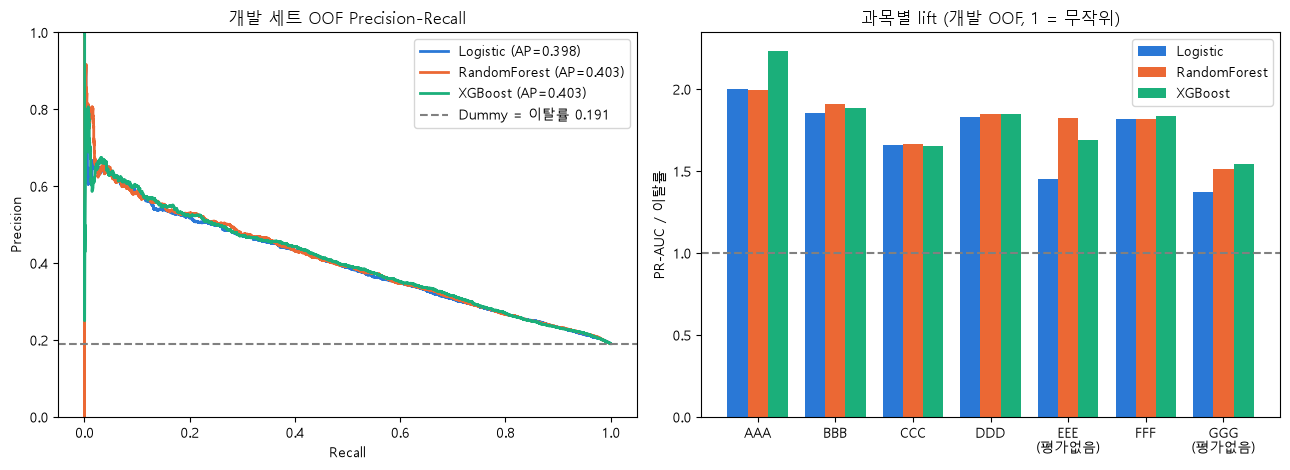

In [12]:
def module_table(frame, y, proba):
    out = []
    for m in MODULES:
        mask = (frame['code_module'] == m).to_numpy()
        if mask.sum() == 0:
            continue
        yy, pp = y[mask], np.asarray(proba)[mask]
        row = {'code_module': m, '행 수': int(mask.sum()), '이탈률': yy.mean(),
               '평가 신호': '없음' if m in NO_ASSESSMENT_MODULES else '있음'}
        if yy.nunique() == 2:
            row['PR-AUC'] = average_precision_score(yy, pp)
            row['lift(PR-AUC/이탈률)'] = row['PR-AUC'] / row['이탈률']
            row['ROC-AUC'] = roc_auc_score(yy, pp)
        out.append(row)
    return pd.DataFrame(out).set_index('code_module')


mod_frames = {name: module_table(dev_df, y_dev, oof_proba[name]) for name in LEARNERS}
dev_module = mod_frames[LEARNERS[0]][['행 수', '이탈률', '평가 신호']].copy()
for name in LEARNERS:
    dev_module[f'{name} PR-AUC'] = mod_frames[name]['PR-AUC']
    dev_module[f'{name} lift'] = mod_frames[name]['lift(PR-AUC/이탈률)']
show(dev_module, {'행 수': '{:,}', '이탈률': '{:.1%}'} | {c: '{:.3f}' for c in dev_module.columns if 'PR-AUC' in c} | {c: '{:.2f}' for c in dev_module.columns if 'lift' in c})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name in LEARNERS:
    p, r, _ = precision_recall_curve(y_dev, oof_proba[name])
    axes[0].plot(r, p, color=MODEL_COLORS[name], lw=2, label=f'{name} (AP={average_precision_score(y_dev, oof_proba[name]):.3f})')
axes[0].axhline(y_dev.mean(), ls='--', c='gray', label=f'Dummy = 이탈률 {y_dev.mean():.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='개발 세트 OOF Precision-Recall', ylim=(0, 1))
axes[0].legend()
x = np.arange(len(dev_module))
w = 0.26
for k, name in enumerate(LEARNERS):
    axes[1].bar(x + (k - 1) * w, dev_module[f'{name} lift'], width=w, color=MODEL_COLORS[name], label=name)
axes[1].axhline(1, ls='--', c='gray')
axes[1].set_xticks(x, [f'{m}\n(평가없음)' if m in NO_ASSESSMENT_MODULES else m for m in dev_module.index])
axes[1].set(ylabel='PR-AUC / 이탈률', title='과목별 lift (개발 OOF, 1 = 무작위)')
axes[1].legend()
plt.tight_layout()
plt.show()

**해석**

- **실사용 지표에서도 세 모델은 거의 같다.** 각자 F1 최대 임계값에서 F1은 0.442 / 0.447 / 0.447이다. 위험군 비율만 31.9% / 28.7% / 26.5%로 다르다.
- **과목별 lift는 대부분 비슷하지만, 평가 신호가 없는 과목에서 차이가 난다.**
  - EEE: Logistic 1.45 vs RandomForest 1.83 vs XGBoost 1.69
  - GGG: Logistic 1.37 vs RandomForest 1.51 vs XGBoost 1.54

  평가 피처가 없으면 VLE 활동의 비선형 패턴에 의존해야 해서, 선형 모델이 불리하다.
- **GGG는 모든 모델에서 가장 약하다**(lift 1.37–1.54, 개발 이탈률 5.9%). CCC는 PR-AUC 절대값은 가장 높지만(0.52–0.53) 기준 이탈률이
  31.7%라 lift는 1.66으로 낮은 편이다.
- AAA는 표본이 370행뿐이라 모델 간 차이(2.00 vs 2.23)를 해석하지 않는다.

## 9. 챔피언 선정

**사전 규칙(첫 버전부터 유지)**: 최종 피처셋 기준 **CV 평균 PR-AUC가 가장 높은 모델**을 챔피언으로 한다. 1·2위 차이가 1위의 fold
표준편차보다 작으면 "통계적으로 구분되지 않음"으로 기록한다.

이번 개정에서는 규칙을 바꾸지 않되, **학기 단위 검증 순위가 CV 순위와 다르면 함께 기록**해 최종 모델 결정의 근거로 남긴다.

In [13]:
if ADOPT_REL:
    final_term = {name: np.mean(split_scores(name, FINAL_NUM, TERM_SPLITS)) for name in LEARNERS}
else:
    final_term = term_table['학기 단위 평균'].to_dict()

rank = pd.DataFrame({
    'CV PR-AUC 평균': {n: np.mean(fold_pr[n]) for n in LEARNERS},
    'CV 표준편차': {n: np.std(fold_pr[n]) for n in LEARNERS},
    '학기 단위 평균': final_term,
}).sort_values('CV PR-AUC 평균', ascending=False)
rank['CV 순위'] = range(1, len(rank) + 1)
rank['학기 단위 순위'] = rank['학기 단위 평균'].rank(ascending=False).astype(int)
show(rank, {'CV PR-AUC 평균': '{:.4f}', 'CV 표준편차': '{:.4f}', '학기 단위 평균': '{:.4f}'})

CHAMPION, RUNNER_UP = rank.index[0], rank.index[1]
gap = rank.loc[CHAMPION, 'CV PR-AUC 평균'] - rank.loc[RUNNER_UP, 'CV PR-AUC 평균']
paired = np.array(fold_pr[CHAMPION]) - np.array(fold_pr[RUNNER_UP])
print(f'챔피언: {CHAMPION} / 2위: {RUNNER_UP}')
print(f'차이 {gap:.4f} vs 1위 fold 표준편차 {rank.loc[CHAMPION, "CV 표준편차"]:.4f} → '
      f'{"구분 가능" if gap >= rank.loc[CHAMPION, "CV 표준편차"] else "통계적으로 구분되지 않음"}')
print(f'fold별 쌍대 차이: {np.round(paired, 4)} (챔피언 우세 {int((paired > 0).sum())}/{len(paired)})')
print(f'학기 단위 1위: {rank["학기 단위 평균"].idxmax()} ({"CV 순위와 일치" if rank["학기 단위 평균"].idxmax() == CHAMPION else "CV 순위와 다름"})')

,CV PR-AUC 평균,CV 표준편차,학기 단위 평균,CV 순위,학기 단위 순위
RandomForest,0.4061,0.0153,0.3430,1,2
XGBoost,0.4055,0.0129,0.3604,2,1
Logistic,0.4004,0.0148,0.3181,3,3


챔피언: RandomForest / 2위: XGBoost
차이 0.0006 vs 1위 fold 표준편차 0.0153 → 통계적으로 구분되지 않음
fold별 쌍대 차이: [ 0.0033 -0.0037  0.0013  0.0125 -0.0104] (챔피언 우세 3/5)
학기 단위 1위: XGBoost (CV 순위와 다름)


**해석**

- **사전 규칙에 따른 챔피언은 RandomForest다.** 다만 XGBoost와의 차이는 0.0006으로 fold 표준편차(0.0153)보다 훨씬 작다.
  fold 쌍대 비교도 3승 2패로 **성능상 동점**이다.
- **학기 단위 검증 1위는 XGBoost다**(0.360 vs 0.343). 학기가 바뀌었을 때의 최솟값도 XGBoost가 높다(0.324 vs 0.296).
- 12절 holdout은 규칙대로 RandomForest로 평가한다. **최종 모델은 해석 결과까지 본 뒤 결정**한다. 판단 근거는 다음 표와 같다.

| 기준 | RandomForest | XGBoost | Logistic |
|---|---|---|---|
| CV PR-AUC | **0.4061** | 0.4055 | 0.4004 |
| 학기 단위 평균 / 최소 | 0.343 / 0.296 | **0.360 / 0.324** | 0.318 / 0.311 |
| 평가 신호 없는 과목(EEE·GGG) lift | **1.83** / 1.51 | 1.69 / **1.54** | 1.45 / 1.37 |
| 튜닝 시간(같은 조건) | 523초 | **108초** | 8초 |
| 해석 | permutation importance | permutation importance·SHAP | **계수 직접 해석** |

> XGBoost로 바꾸기로 한다면, 그 결정은 **개발 세트 근거(학기 단위 안정성·속도)로 내린 것**이어야 한다.
> holdout은 바꾼 모델로 한 번만 다시 평가한다. RandomForest의 holdout 결과를 보고 모델을 바꾸는 것은 holdout 재사용이다.

## 10. 확률 보정

**왜 필요한가**: `class_weight='balanced'`·`scale_pos_weight`는 양성 쪽으로 확률을 옮겨 **순위는 유지하지만 크기를 부풀린다**
(감사 보고서 2.3절: 예측 0.785 구간의 실제 이탈률 0.487). 확률을 "이탈 위험 %"로 쓰거나 임계값을 해석하려면 보정이 필요하다.

**방법 — 교차 적합 보정, 두 방식 비교**

| 방식 | 특징 |
|---|---|
| sigmoid(Platt) | 원 확률의 logit에 로지스틱 회귀. **순증가 함수라 순위가 완전히 보존**된다(PR-AUC·ROC-AUC 불변) |
| isotonic | 계단형 단조 함수. 모양 제약이 없어 더 유연하지만 **동점 구간이 생겨 순위 해상도를 잃는다** |

1. 개발 OOF로 평가할 때는 **fold k의 보정기를 나머지 fold의 OOF로만 학습**한다(보정에도 누수가 없도록).
2. **사전 선택 규칙**: 교차 적합 Brier가 더 낮은 방식을 쓴다. 단 차이가 0.001 미만이면 순위를 보존하는 sigmoid를 쓴다.
3. holdout용 최종 보정기는 선택한 방식으로 개발 OOF 전체에 학습해, 개발 세트 전체로 재학습한 챔피언의 holdout 확률에 적용한다.

평가: Brier score(낮을수록 좋음), PR-AUC 변화(순위 손실), 10분위 신뢰도 표(평균 예측 vs 실제 이탈률).

첫 실행에서 isotonic만 썼을 때 개발 OOF PR-AUC가 0.4032 → 0.3951, holdout PR-AUC가 0.3649 → 0.3535로 떨어져 비교 방식을 추가했다.

,PR-AUC,ROC-AUC,Brier,평균 예측,고유값 수
보정 전,0.4032,0.7265,0.2006,0.4349,"18,503"
sigmoid,0.4027,0.7263,0.1364,0.1906,"18,503"
isotonic,0.3951,0.7246,0.1365,0.1906,234


Brier 차이(sigmoid − isotonic) = -0.0001 → 선택: sigmoid


,보정 전,"보정 후(sigmoid, 교차 적합)"
PR-AUC,0.4032,0.4027
ROC-AUC,0.7265,0.7263
Brier,0.2006,0.1364
평균 예측,0.4349,0.1906
실제 이탈률,0.1906,0.1906


보정 전                보정 후             
      평균예측  실제이탈률    행수   평균예측  실제이탈률    행수
bin                                        
0    0.158  0.045  1851  0.045  0.044  1851
1    0.244  0.079  1850  0.075  0.079  1850
2    0.297  0.103  1850  0.097  0.105  1850
3    0.341  0.112  1851  0.116  0.111  1851
4    0.381  0.131  1850  0.135  0.133  1850
5    0.426  0.151  1850  0.159  0.149  1850
6    0.484  0.195  1851  0.194  0.196  1851
7    0.565  0.258  1850  0.250  0.258  1850
8    0.668  0.328  1850  0.343  0.328  1850
9    0.785  0.504  1851  0.491  0.502  1851

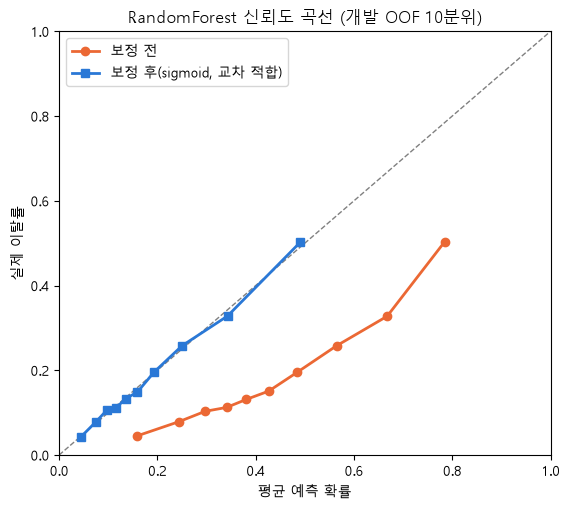

In [14]:
def _logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


def fit_calibrator(method, p, y):
    if method == 'isotonic':
        return IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(p, y)
    return LogisticRegression(C=1e6, max_iter=1000).fit(_logit(p), y)


def apply_calibrator(method, cal, p):
    return cal.predict(p) if method == 'isotonic' else cal.predict_proba(_logit(p))[:, 1]


raw_oof = oof_proba[CHAMPION]
cross_fit = {}
for method in ['sigmoid', 'isotonic']:
    out = np.zeros_like(raw_oof)
    for _, va in CV_SPLITS:
        other = np.setdiff1d(np.arange(len(dev_df)), va)
        out[va] = apply_calibrator(method, fit_calibrator(method, raw_oof[other], y_dev.iloc[other]), raw_oof[va])
    cross_fit[method] = out

method_table = pd.DataFrame({
    m: {'PR-AUC': average_precision_score(y_dev, p), 'ROC-AUC': roc_auc_score(y_dev, p), 'Brier': brier_score_loss(y_dev, p),
        '평균 예측': p.mean(), '고유값 수': len(np.unique(np.round(p, 10)))}
    for m, p in {'보정 전': raw_oof, **cross_fit}.items()
}).T
show(method_table, {'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Brier': '{:.4f}', '평균 예측': '{:.4f}', '고유값 수': '{:,.0f}'})

b_sig, b_iso = method_table.loc['sigmoid', 'Brier'], method_table.loc['isotonic', 'Brier']
CAL_METHOD = 'isotonic' if (b_sig - b_iso) >= 0.001 else 'sigmoid'
print(f'Brier 차이(sigmoid − isotonic) = {b_sig - b_iso:+.4f} → 선택: {CAL_METHOD}')
cal_oof = cross_fit[CAL_METHOD]
CALIBRATOR = fit_calibrator(CAL_METHOD, raw_oof, y_dev)


def reliability(y_true, proba, bins=10):
    q = pd.qcut(pd.Series(proba).rank(method='first'), bins, labels=False)
    return pd.DataFrame({'y': np.asarray(y_true), 'p': proba, 'bin': q}).groupby('bin').agg(평균예측=('p', 'mean'), 실제이탈률=('y', 'mean'), 행수=('y', 'size'))


cal_summary = pd.DataFrame({
    '보정 전': {'PR-AUC': average_precision_score(y_dev, raw_oof), 'ROC-AUC': roc_auc_score(y_dev, raw_oof),
              'Brier': brier_score_loss(y_dev, raw_oof), '평균 예측': raw_oof.mean()},
    f'보정 후({CAL_METHOD}, 교차 적합)': {'PR-AUC': average_precision_score(y_dev, cal_oof), 'ROC-AUC': roc_auc_score(y_dev, cal_oof),
                     'Brier': brier_score_loss(y_dev, cal_oof), '평균 예측': cal_oof.mean()},
})
cal_summary.loc['실제 이탈률'] = [y_dev.mean(), y_dev.mean()]
display(cal_summary.round(4))

rel_raw, rel_cal = reliability(y_dev, raw_oof), reliability(y_dev, cal_oof)
display(pd.concat({'보정 전': rel_raw, '보정 후': rel_cal}, axis=1).round(3))

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.plot([0, 1], [0, 1], ls='--', c='gray', lw=1)
ax.plot(rel_raw['평균예측'], rel_raw['실제이탈률'], marker='o', color='#eb6834', lw=2, label='보정 전')
ax.plot(rel_cal['평균예측'], rel_cal['실제이탈률'], marker='s', color='#2a78d6', lw=2, label=f'보정 후({CAL_METHOD}, 교차 적합)')
ax.set(xlabel='평균 예측 확률', ylabel='실제 이탈률', title=f'{CHAMPION} 신뢰도 곡선 (개발 OOF 10분위)', xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

**해석**

- **사전 규칙에 따라 sigmoid를 선택했다.** Brier는 sigmoid 0.1364, isotonic 0.1365로 차이가 0.0001뿐이라 순위를 보존하는 쪽을 택했다.
- **보정으로 확률 크기가 실제와 맞춰졌다.**
  - 평균 예측이 0.435에서 0.191로 내려와 실제 이탈률 0.191과 같아졌다.
  - Brier는 0.2006에서 0.1364로 32% 줄었다.
  - 10분위 신뢰도 표에서 모든 구간의 예측과 실제 차이가 1.5%p 이내다.
- **순위는 유지됐다.** sigmoid PR-AUC 0.4027(보정 전 0.4032)이다. 남은 0.0005 차이는 fold마다 다른 보정기를 쓴 교차 적합의 산물이다.
  하나의 보정기를 쓰는 holdout에서는 보정 전후 PR-AUC가 완전히 같다(12절). 반면 isotonic은 고유값이 234개로 줄면서 PR-AUC가 0.3951로 떨어졌다.
- 이제 **보정 확률을 "이탈 위험 %"로 읽을 수 있다.** 첫 버전의 임계값 0.525는 실제로는 20–25% 위험 구간이었다.

## 11. 임계값 후보 비교

실제 개입 수단·인력이 아직 정해지지 않았으므로 **후보를 모두 계산해 두고 잠정 기본값 하나를 둔다.** 최종 선택은 운영 조건(개입 수단·인력)을 정한 뒤로 미룬다.
모든 임계값은 **보정된 개발 OOF 확률로만** 정하고 holdout에는 고정해 적용한다.

| 기준 | 의미 | 어울리는 개입 |
|---|---|---|
| **전역 F1 최대 (잠정 기본값)** | Precision·Recall 균형 | 1:1 상담처럼 비용이 중간인 개입 |
| 전역 F2 최대 | Recall 중시 | 알림처럼 저비용 개입 (단, 위험군이 과도하게 커질 수 있음) |
| 전역 Recall ≥ 0.70 중 Precision 최대 | 이탈자 70% 이상 포착 | 놓치는 비용이 큰 경우 |
| 전역 상위 20% / 30% | 개입 인력이 고정 | 튜터 수가 정해진 경우 |
| **과목별 상위 k%** | 각 과목·학기 재학생 안에서 상위 k%를 표시 (k = 전역 F1 최대의 위험군 비율) | 과목마다 튜터가 배정된 경우. 기준 이탈률이 낮은 과목(GGG 등)도 대상자가 생김 |

과목별 상위 k%는 확률 절대값이 아니라 **같은 과목·학기 안의 순위**를 쓴다. 배포 시점에 그 학기 재학생 전체의 점수로 계산할 수 있어 누수가 아니다.

In [15]:
def module_topk_flags(frame, proba, k):
    # 같은 (과목, 학기) 안에서 확률 상위 k 비율을 표시
    s = pd.Series(proba, index=frame.index)
    pct = s.groupby([frame['code_module'], frame['code_presentation']]).rank(pct=True, method='first', ascending=False)
    return (pct <= k).astype(int).to_numpy()


def flag_metrics(y_true, flags):
    tn, fp, fn, tp = confusion_matrix(y_true, flags, labels=[0, 1]).ravel()
    return {'threshold': np.nan, 'precision': precision_score(y_true, flags, zero_division=0), 'recall': recall_score(y_true, flags, zero_division=0),
            'f1': f1_score(y_true, flags, zero_division=0), 'f2': fbeta_score(y_true, flags, beta=2, zero_division=0),
            'flag_rate': flags.mean(), 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}


p_, r_, t_ = precision_recall_curve(y_dev, cal_oof)
p_, r_ = p_[:-1], r_[:-1]
ok = r_ >= 0.70
THRESHOLDS = {
    '전역 F1 최대': best_f_threshold(y_dev, cal_oof, 1.0),
    '전역 F2 최대': best_f_threshold(y_dev, cal_oof, 2.0),
    '전역 Recall≥0.70 중 Precision 최대': float(t_[ok][np.argmax(p_[ok])]),
    '전역 상위 20%': float(np.quantile(cal_oof, 0.80)),
    '전역 상위 30%': float(np.quantile(cal_oof, 0.70)),
}
thr_rows = [{'기준': k, **threshold_metrics(y_dev, cal_oof, v)} for k, v in THRESHOLDS.items()]
TOPK = float((cal_oof >= THRESHOLDS['전역 F1 최대']).mean())
thr_rows.append({'기준': f'과목별 상위 {TOPK:.0%}', **flag_metrics(y_dev, module_topk_flags(dev_df, cal_oof, TOPK))})
threshold_table = pd.DataFrame(thr_rows).set_index('기준')
show(threshold_table, {'threshold': '{:.4f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}', 'f2': '{:.3f}', 'flag_rate': '{:.1%}'})

THRESHOLD_RULE = '전역 F1 최대'
THRESHOLD = THRESHOLDS[THRESHOLD_RULE]
print(f'잠정 기본값: {THRESHOLD_RULE} → 보정 확률 {THRESHOLD:.4f} (= 이 이상이면 실제 이탈 위험 약 {THRESHOLD:.0%} 이상)')

# 과목별 Recall: 전역 임계값 vs 과목별 상위 k%
g_flag = (cal_oof >= THRESHOLD).astype(int)
m_flag = module_topk_flags(dev_df, cal_oof, TOPK)
per_mod = []
for m in MODULES:
    mask = (dev_df['code_module'] == m).to_numpy()
    if not mask.any():
        continue
    yy = y_dev[mask]
    per_mod.append({'code_module': m, '이탈률': yy.mean(), '평가 신호': '없음' if m in NO_ASSESSMENT_MODULES else '있음',
                    '전역: 위험군 비율': g_flag[mask].mean(), '전역: Recall': recall_score(yy, g_flag[mask], zero_division=0),
                    '전역: Precision': precision_score(yy, g_flag[mask], zero_division=0),
                    f'과목별 {TOPK:.0%}: Recall': recall_score(yy, m_flag[mask], zero_division=0),
                    f'과목별 {TOPK:.0%}: Precision': precision_score(yy, m_flag[mask], zero_division=0)})
dev_rule_by_module = pd.DataFrame(per_mod).set_index('code_module')
show(dev_rule_by_module, {c: '{:.1%}' if ('비율' in c or '이탈률' in c) else '{:.3f}' for c in dev_rule_by_module.columns if c != '평가 신호'})

,threshold,precision,recall,f1,f2,flag_rate,tp,fp,fn,tn
기준,,,,,,,,,,
전역 F1 최대,0.2262,0.373,0.557,0.447,0.507,28.4%,1963,3301,1563,11677
전역 F2 최대,0.1137,0.248,0.860,0.384,0.575,66.2%,3032,9216,494,5762
전역 Recall≥0.70 중 Precision 최대,0.1640,0.309,0.701,0.429,0.559,43.2%,2470,5528,1056,9450
전역 상위 20%,0.2880,0.415,0.436,0.425,0.432,20.0%,1537,2164,1989,12814
전역 상위 30%,0.2172,0.363,0.571,0.444,0.512,30.0%,2014,3537,1512,11441
과목별 상위 28%,,0.328,0.490,0.393,0.446,28.4%,1726,3530,1800,11448


잠정 기본값: 전역 F1 최대 → 보정 확률 0.2262 (= 이 이상이면 실제 이탈 위험 약 23% 이상)


,이탈률,평가 신호,전역: 위험군 비율,전역: Recall,전역: Precision,과목별 28%: Recall,과목별 28%: Precision
code_module,,,,,,,
AAA,13.0%,있음,17.8%,0.396,0.288,0.458,0.210
BBB,15.7%,있음,18.6%,0.380,0.320,0.488,0.269
CCC,31.7%,있음,67.0%,0.857,0.405,0.450,0.502
DDD,26.0%,있음,46.7%,0.721,0.402,0.521,0.478
EEE,13.4%,없음,12.6%,0.272,0.289,0.461,0.218
FFF,19.7%,있음,27.3%,0.497,0.359,0.502,0.349
GGG,5.9%,없음,0.0%,0.000,0.000,0.324,0.067


**해석**

- **전역 F1 최대(잠정 기본값)**: 보정 확률 0.226 이상, 즉 **이탈 위험 약 23% 이상**을 위험군으로 본다.
  재학생의 28.4%가 표시되고, Precision 0.373, Recall 0.557이다.
- F2 최대는 위험군이 66.2%라 선별 의미가 약하다. 상위 20%는 Precision 0.415, Recall 0.436이다.
- **전역 기준과 과목별 상위 28%는 "누구를 표시하는가"가 다르다.**

  | 과목 | 이탈률 | 전역: 위험군 / Recall | 과목별 28%: Recall / Precision |
  |---|---:|---|---|
  | CCC | 31.7% | 67.0% / 0.857 | 0.450 / 0.502 |
  | DDD | 26.0% | 46.7% / 0.721 | 0.521 / 0.478 |
  | EEE | 13.4% | 12.6% / 0.272 | 0.461 / 0.218 |
  | GGG | 5.9% | **0.0% / 0.000** | **0.324** / 0.067 |

  - 전역 기준은 **기준 이탈률이 높은 과목에 대상을 몰아준다.** CCC 재학생의 67%가 위험군이고, GGG에서는 한 명도 표시되지 않는다.
  - 과목별 상위 k%는 모든 과목에 대상자를 고르게 배분해 GGG·EEE의 이탈자도 잡는다. 대신 저이탈 과목에서 Precision이 낮아
    **전체 F1은 0.447 → 0.393으로 떨어진다.**
- 어느 쪽이 맞는지는 **개입 구조에 달렸다.** 중앙에서 한정된 인원을 최대한 효율적으로 쓰면 전역 기준, 과목마다 튜터가 있어 과목별로
  일정 비율을 관리해야 하면 과목별 상위 k%가 맞다.

## 12. 챔피언 `2014J` holdout 평가

개발 세트 전체로 챔피언(최종 피처셋·최적 파라미터)을 재학습하고, 10절 최종 보정기와 11절 임계값을 **그대로** 적용한다.
holdout은 여기서 처음이자 마지막으로 쓴다.

해석 시 주의(앞 단계에서 기록한 사항):

- **BBB 2014J의 25일 내 평가는 가중치 0 TMA**다. 점수·제출의 성격이 개발 학기와 다르다(`05_Collinearity_Recheck` 4.4절).
- **GGG는 기준 이탈률이 학기마다 올랐다**(4.0% → 8.1% → 12.9%). 과거 학기로 학습한 모델은 GGG 확률을 낮게 잡을 가능성이 높다.
- **판정 불명 Withdrawn 93건 중 87건이 2014J**라 holdout 이탈자가 약 5% 과소 집계됐을 수 있다(`03_Landmark25_EDA` 13절).

In [16]:
champion_model = make_pipeline(CHAMPION, FINAL_NUM).set_params(**BEST_PARAMS[CHAMPION])
champion_model.fit(dev_df[FINAL_FEATURES], y_dev)
hold_raw = champion_model.predict_proba(hold_df[FINAL_FEATURES])[:, 1]
hold_cal = apply_calibrator(CAL_METHOD, CALIBRATOR, hold_raw)

hold_global = threshold_metrics(y_hold, hold_cal, THRESHOLD)
hold_topk = flag_metrics(y_hold, module_topk_flags(hold_df, hold_cal, TOPK))
dev_row = threshold_table.loc[THRESHOLD_RULE]

hold_summary = pd.DataFrame({
    '개발 OOF(보정)': {'PR-AUC': average_precision_score(y_dev, cal_oof), 'ROC-AUC': roc_auc_score(y_dev, cal_oof),
                     'Brier': brier_score_loss(y_dev, cal_oof), '평균 예측': cal_oof.mean(), '실제 이탈률': y_dev.mean(),
                     **{f'전역F1_{k}': dev_row[k] for k in ('precision', 'recall', 'f1', 'flag_rate')}},
    'holdout 2014J': {'PR-AUC': average_precision_score(y_hold, hold_cal), 'ROC-AUC': roc_auc_score(y_hold, hold_cal),
                      'Brier': brier_score_loss(y_hold, hold_cal), '평균 예측': hold_cal.mean(), '실제 이탈률': y_hold.mean(),
                      **{f'전역F1_{k}': hold_global[k] for k in ('precision', 'recall', 'f1', 'flag_rate')}},
})
hold_summary.loc['PR-AUC / 이탈률'] = [hold_summary.loc['PR-AUC', c] / hold_summary.loc['실제 이탈률', c] for c in hold_summary.columns]
display(hold_summary.round(4))
print(f'holdout 보정 전 PR-AUC {average_precision_score(y_hold, hold_raw):.4f} / 보정 후 {average_precision_score(y_hold, hold_cal):.4f}')

rule_compare = pd.DataFrame({
    f'전역 F1 최대 (임계값 {THRESHOLD:.3f})': hold_global,
    f'과목별 상위 {TOPK:.0%}': hold_topk,
}).T[['precision', 'recall', 'f1', 'flag_rate', 'tp', 'fp', 'fn', 'tn']]
show(rule_compare, {'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}', 'flag_rate': '{:.1%}'})

,개발 OOF(보정),holdout 2014J
PR-AUC,0.4027,0.3649
ROC-AUC,0.7263,0.6808
Brier,0.1364,0.1409
평균 예측,0.1906,0.1798
실제 이탈률,0.1906,0.1880
전역F1_precision,0.3729,0.3150
전역F1_recall,0.5567,0.5250
전역F1_f1,0.4466,0.3937
전역F1_flag_rate,0.2845,0.3133
PR-AUC / 이탈률,2.1136,1.9414


holdout 보정 전 PR-AUC 0.3649 / 보정 후 0.3649


,precision,recall,f1,flag_rate,tp,fp,fn,tn
전역 F1 최대 (임계값 0.226),0.315,0.525,0.394,31.3%,903.0,1964.0,817.0,5466.0
과목별 상위 28%,0.319,0.482,0.384,28.4%,829.0,1770.0,891.0,5660.0


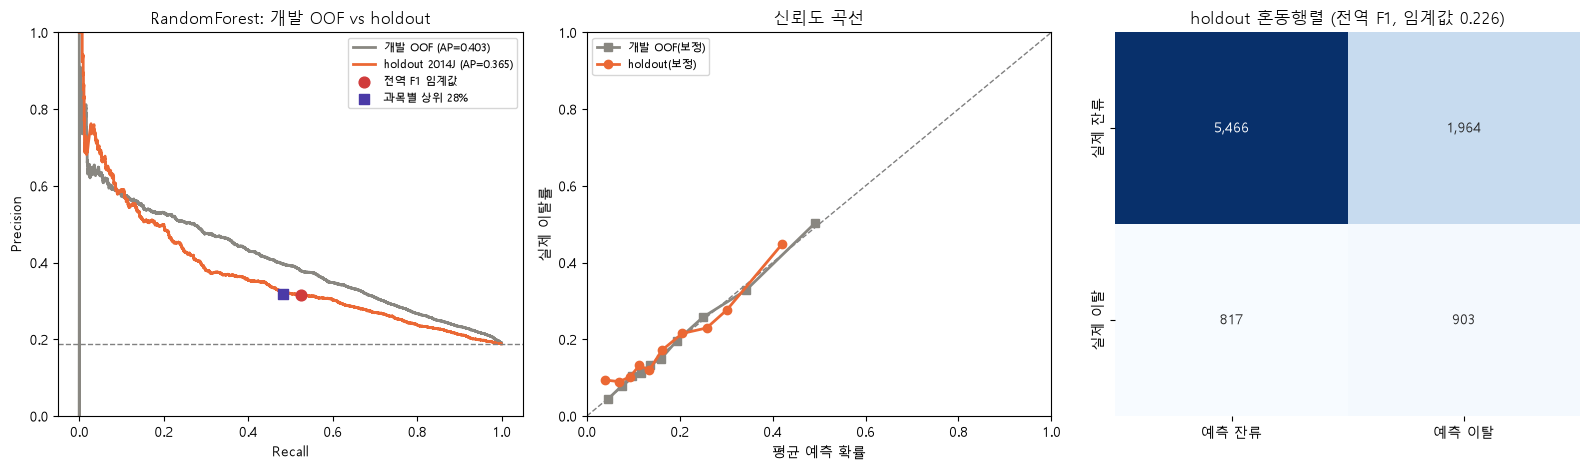

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
p_h, r_h, _ = precision_recall_curve(y_hold, hold_cal)
p_o, r_o, _ = precision_recall_curve(y_dev, cal_oof)
axes[0].plot(r_o, p_o, color='#898781', lw=2, label=f'개발 OOF (AP={average_precision_score(y_dev, cal_oof):.3f})')
axes[0].plot(r_h, p_h, color=MODEL_COLORS[CHAMPION], lw=2, label=f'holdout 2014J (AP={average_precision_score(y_hold, hold_cal):.3f})')
axes[0].axhline(y_hold.mean(), ls='--', c='gray', lw=1)
axes[0].scatter([hold_global['recall']], [hold_global['precision']], c='#d03b3b', zorder=5, s=60, label='전역 F1 임계값')
axes[0].scatter([hold_topk['recall']], [hold_topk['precision']], c='#4a3aa7', marker='s', zorder=5, s=60, label=f'과목별 상위 {TOPK:.0%}')
axes[0].set(xlabel='Recall', ylabel='Precision', title=f'{CHAMPION}: 개발 OOF vs holdout', ylim=(0, 1))
axes[0].legend(fontsize=8)

rel_h = reliability(y_hold, hold_cal)
axes[1].plot([0, 1], [0, 1], ls='--', c='gray', lw=1)
axes[1].plot(rel_cal['평균예측'], rel_cal['실제이탈률'], marker='s', color='#898781', lw=2, label='개발 OOF(보정)')
axes[1].plot(rel_h['평균예측'], rel_h['실제이탈률'], marker='o', color=MODEL_COLORS[CHAMPION], lw=2, label='holdout(보정)')
axes[1].set(xlabel='평균 예측 확률', ylabel='실제 이탈률', title='신뢰도 곡선', xlim=(0, 1), ylim=(0, 1))
axes[1].legend(fontsize=8)

cm_h = confusion_matrix(y_hold, (hold_cal >= THRESHOLD).astype(int))
sns.heatmap(cm_h, annot=True, fmt=',', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['예측 잔류', '예측 이탈'], yticklabels=['실제 잔류', '실제 이탈'])
axes[2].set_title(f'holdout 혼동행렬 (전역 F1, 임계값 {THRESHOLD:.3f})')
plt.tight_layout()
plt.show()

### 12.1 holdout 과목별 성능

전역 임계값과 과목별 상위 k%를 과목 단위로 비교한다. "평균 예측 − 실제"는 보정 확률이 그 과목의 기준 이탈률을 얼마나 틀리게 잡는지 보여준다
(음수 = 과소 예측).

In [18]:
h_mod = module_table(hold_df, y_hold, hold_cal)
g_flag_h = (hold_cal >= THRESHOLD).astype(int)
m_flag_h = module_topk_flags(hold_df, hold_cal, TOPK)
for m in h_mod.index:
    mask = (hold_df['code_module'] == m).to_numpy()
    yy = y_hold[mask]
    h_mod.loc[m, '평균 예측 − 실제'] = hold_cal[mask].mean() - yy.mean()
    h_mod.loc[m, '전역: 위험군 비율'] = g_flag_h[mask].mean()
    h_mod.loc[m, '전역: Recall'] = recall_score(yy, g_flag_h[mask], zero_division=0)
    h_mod.loc[m, '전역: Precision'] = precision_score(yy, g_flag_h[mask], zero_division=0)
    h_mod.loc[m, f'과목별 {TOPK:.0%}: Recall'] = recall_score(yy, m_flag_h[mask], zero_division=0)
    h_mod.loc[m, f'과목별 {TOPK:.0%}: Precision'] = precision_score(yy, m_flag_h[mask], zero_division=0)
    h_mod.loc[m, '개발 OOF lift'] = mod_frames[CHAMPION].loc[m, 'lift(PR-AUC/이탈률)'] if m in mod_frames[CHAMPION].index else np.nan
h_mod['비고'] = ''
h_mod.loc[h_mod.index.intersection(['BBB']), '비고'] = '25일 내 평가가 가중치 0 TMA'
h_mod.loc[h_mod.index.intersection(['GGG']), '비고'] = '기준 이탈률 상승 과목'
fmt = {'행 수': '{:,}', '이탈률': '{:.1%}', 'PR-AUC': '{:.3f}', 'lift(PR-AUC/이탈률)': '{:.2f}', 'ROC-AUC': '{:.3f}',
       '평균 예측 − 실제': '{:+.1%}', '전역: 위험군 비율': '{:.1%}', '개발 OOF lift': '{:.2f}'}
fmt |= {c: '{:.3f}' for c in h_mod.columns if 'Recall' in c or 'Precision' in c}
show(h_mod, fmt)

,행 수,이탈률,평가 신호,PR-AUC,lift(PR-AUC/이탈률),ROC-AUC,평균 예측 − 실제,전역: 위험군 비율,전역: Recall,전역: Precision,과목별 28%: Recall,과목별 28%: Precision,개발 OOF lift,비고
code_module,,,,,,,,,,,,,,
AAA,348,14.1%,있음,0.223,1.59,0.649,+3.5%,24.1%,0.388,0.226,0.469,0.235,1.99,
BBB,"1,776",13.2%,있음,0.177,1.34,0.586,+5.1%,43.6%,0.521,0.157,0.368,0.170,1.91,25일 내 평가가 가중치 0 TMA
CCC,"2,006",29.2%,있음,0.514,1.76,0.708,-7.3%,40.7%,0.628,0.451,0.488,0.502,1.66,
DDD,"1,450",20.3%,있음,0.395,1.95,0.695,+1.5%,40.1%,0.612,0.310,0.503,0.359,1.85,
EEE,"1,017",13.4%,없음,0.274,2.05,0.685,-0.1%,13.5%,0.316,0.314,0.493,0.232,1.83,
FFF,"1,838",17.9%,있음,0.367,2.05,0.710,+0.6%,25.8%,0.520,0.361,0.556,0.351,1.81,
GGG,715,12.9%,없음,0.171,1.33,0.590,-8.8%,0.0%,0.000,0.000,0.391,0.177,1.51,기준 이탈률 상승 과목


**해석**

- **미래 학기에서도 무작위보다 약 2배 낫다.** holdout PR-AUC 0.3649로 이탈률의 1.94배이고, ROC-AUC는 0.681이다.
  개발 OOF(0.4027, 2.11배)보다 낮은데, 6절 학기 단위 검증(RandomForest 0.343)을 보면 **예상 범위 안의 하락**이다.
- **전체 보정은 유지됐다.** holdout 평균 예측은 18.0%, 실제는 18.8%다. Brier는 0.141로 개발 세트(0.136)와 비슷하다.
  신뢰도 곡선에서는 가장 낮은 구간(예측 약 4%)의 실제 이탈률이 약 9%로, **저위험 구간을 과소 예측**한다(아래 GGG).
- **전역 F1 임계값의 holdout 성능**: Precision 0.315, Recall 0.525, F1 0.394, 위험군 31.3%다(개발 28.4%).
- **과목별 결과가 앞 단계에서 기록한 위험과 정확히 일치한다.**
  - **BBB — 과대 예측 +5.1%p, 위험군 43.6%, Precision 0.157.** 25일 내 평가가 가중치 0 TMA라 점수가 낮게 나오고, 모델은 낮은 점수를 위험으로
    읽었다(`05_Collinearity_Recheck` 4.4절에서 예고). 정의 변경 전에는 "BBB × 기회 0"이라는 학습에 없던 조합이었고, 지금은 "성격이 다른 점수"다.
    둘 다 BBB 2014J의 평가 설계 변경에서 온 한계다.
  - **GGG — 과소 예측 −8.8%p, 위험군 0명.** 개발 학기 GGG 이탈률(5.9%)보다 holdout(12.9%)이 두 배 높다(`03_Landmark25_EDA` 3절).
    보정은 과거 수준에 맞춰지므로 **기준 이탈률이 오르는 과목은 보정으로 해결되지 않는다.**
  - CCC도 −7.3%p 과소 예측이지만 PR-AUC 0.514로 순위는 잘 맞힌다. FFF·EEE·DDD는 예측 수준 차이 ±1.5%p 이내로 안정적이다.
- **과목별 상위 28%**는 전체 F1이 0.384로 전역 기준(0.394)과 비슷하다. 대신 **GGG Recall을 0 → 0.391로 끌어올리고**
  BBB의 과다 표시(43.6% → 28%)를 막는다. 학기가 바뀌어 과목별 확률 수준이 틀어질 때 **순위 기반 기준이 더 견고하다**는 증거다.
- 첫 버전 holdout(PR-AUC 0.3722)보다 0.007 낮다. 정의 변경, 최적 파라미터 변화(`max_depth` None → 12)가 함께 바뀌어 원인을 분리할 수 없고,
  6절 기준으로 보면 오차 범위의 차이다.
- 판정 불명 Withdrawn 87건이 2014J에서 빠져 있어, holdout 이탈자가 약 5% 과소 집계됐을 수 있다(민감도 분석은 `06_Sensitivity_Ambiguous`).

## 13. 결과 저장

재생성 가능한 일반 산출물을 `CSV_files/모델링/`에 저장한다. 그래프를 다시 그릴 때 모델을 재학습하지 않도록 예측값도 저장한다.

| 파일 | 내용 |
|---|---|
| `baseline_cv_comparison_n25.csv` | 모델별 CV·학기 단위·OOF 지표, 최적 파라미터 |
| `feature_set_comparison_n25.csv` | 기본 vs 상대 피처셋 비교 |
| `dev_oof_predictions_n25.csv` | 개발 세트 OOF 확률(모델별, 챔피언 보정 확률 포함) |
| `holdout_predictions_n25.csv` | 챔피언 holdout 확률(보정 전·후), 전역·과목별 표시 |
| `module_performance_n25.csv` | 과목별 성능(개발 OOF, holdout) |
| `champion_summary_n25.json` | 챔피언, 피처, 파라미터, 분할, 보정, 임계값 후보, holdout 지표, 환경 |

재현 스냅샷(노트북·산출물·모델 파일·해시)은 최종 모델·임계값을 확정하고 커밋한 뒤 저장소 밖에 따로 보관한다.

In [19]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison = cv_table.drop(columns='best_params').join(term_table[[c for c in term_table.columns if c.startswith('검증') or '학기 단위' in c]]).join(oof_table)
comparison['best_params'] = cv_table['best_params']
comparison.to_csv(OUTPUT_DIR / 'baseline_cv_comparison_n25.csv', encoding='utf-8-sig')
rel_table.assign(adopted=ADOPT_REL).to_csv(OUTPUT_DIR / 'feature_set_comparison_n25.csv', encoding='utf-8-sig')

dev_out = dev_df[GRAIN].assign(**{TARGET: y_dev.values}, **{f'oof_{n}': oof_proba[n] for n in LEARNERS}, champion_calibrated=cal_oof)
assert not dev_out.duplicated(GRAIN).any() and len(dev_out) == len(dev_df)
dev_out.to_csv(OUTPUT_DIR / 'dev_oof_predictions_n25.csv', index=False, encoding='utf-8-sig')

hold_out = hold_df[GRAIN].assign(**{TARGET: y_hold.values}, pred_proba_raw=hold_raw, pred_proba=hold_cal,
                                 flag_global_f1=g_flag_h, flag_module_topk=m_flag_h)
assert not hold_out.duplicated(GRAIN).any() and len(hold_out) == 9150
hold_out.to_csv(OUTPUT_DIR / 'holdout_predictions_n25.csv', index=False, encoding='utf-8-sig')

pd.concat({'dev_oof': mod_frames[CHAMPION], 'holdout': h_mod}, names=['set']).to_csv(OUTPUT_DIR / 'module_performance_n25.csv', encoding='utf-8-sig')


def to_py(o):
    return o.item() if hasattr(o, 'item') else str(o)


summary = {
    'created_from': 'Notebooks/03_Modeling/01_Baseline_Models.ipynb',
    'feature_spec': 'CSV_files/통합 버전/feature_spec_n25.json',
    'definition_version': spec.get('definition_version'),
    'relative_features': {'candidates': REL_FEATURES, 'adopted': ADOPT_REL,
                          'rule': 'mean delta over Logistic/RF/XGB > 0 on both CV_SPLITS and TERM_SPLITS'},
    'features_in_order': FINAL_FEATURES,
    'champion': CHAMPION,
    'best_params': BEST_PARAMS,
    'cv': {'splitter': 'StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)', 'groups': GROUP_COL,
           'dev_terms': DEV_TERMS, 'n_dev': len(dev_df),
           'pr_auc_mean': {n: float(np.mean(fold_pr[n])) for n in LEARNERS},
           'term_split_pr_auc_mean': {n: float(v) for n, v in final_term.items()}, 'term_split_folds': TERM_NAMES},
    'calibration': {'method': f'{CAL_METHOD} on dev OOF (cross-fitted for evaluation; rule: lower Brier, sigmoid if diff < 0.001)',
                    'dev_brier_raw': brier_score_loss(y_dev, raw_oof), 'dev_brier_calibrated': brier_score_loss(y_dev, cal_oof)},
    'threshold_candidates': {k: float(v) for k, v in THRESHOLDS.items()} | {'module_topk_rate': TOPK},
    'threshold_provisional': {'rule': THRESHOLD_RULE, 'value': THRESHOLD, 'chosen_on': 'calibrated dev OOF'},
    'holdout': {'term': HOLDOUT_TERM, 'n': len(hold_df), 'pr_auc': average_precision_score(y_hold, hold_cal),
                'roc_auc': roc_auc_score(y_hold, hold_cal), 'brier': brier_score_loss(y_hold, hold_cal), 'prevalence': y_hold.mean(),
                'global_f1': {k: hold_global[k] for k in ('precision', 'recall', 'f1', 'flag_rate')},
                'module_topk': {k: hold_topk[k] for k in ('precision', 'recall', 'f1', 'flag_rate')}},
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'environment': {'python': platform.python_version(), 'pandas': pd.__version__, 'scikit-learn': sklearn.__version__, 'xgboost': xgboost.__version__},
}
with open(OUTPUT_DIR / 'champion_summary_n25.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=to_py)

reloaded = pd.read_csv(OUTPUT_DIR / 'holdout_predictions_n25.csv')
assert len(reloaded) == 9150 and np.allclose(reloaded['pred_proba'], hold_cal)
with open(OUTPUT_DIR / 'champion_summary_n25.json', encoding='utf-8') as f:
    assert json.load(f)['champion'] == CHAMPION
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'{p.relative_to(PROJECT_ROOT)}  ({p.stat().st_size / 1024:.1f} KB)')

CSV_files\모델링\baseline_cv_comparison_n25.csv  (1.6 KB)
CSV_files\모델링\champion_summary_n25.json  (3.4 KB)
CSV_files\모델링\dev_oof_predictions_n25.csv  (1763.4 KB)
CSV_files\모델링\feature_set_comparison_n25.csv  (0.5 KB)
CSV_files\모델링\holdout_predictions_n25.csv  (563.7 KB)
CSV_files\모델링\module_performance_n25.csv  (2.6 KB)


## 14. 결론

### 확정된 것

1. **피처**: 기본 20개(`n_banked_25` 포함). 과목·학기 내 상대 피처는 사전 규칙상 미채택(학기 단위 검증에서 세 모델 모두 하락).
2. **보정**: sigmoid. 확률이 실제 이탈률 수준으로 맞춰졌고(개발 Brier 0.2006 → 0.1364) 순위는 보존된다.
3. **성능 수준**: 25일 시점 정보로 이탈을 무작위의 약 2배 PR-AUC로 가려낸다(개발 2.11배, holdout 1.94배).
   **세 모델의 CV 성능은 동점**이며, 성능 상한은 모델 종류보다 25일 시점 정보량이 정한다.
4. **학기 단위 검증이 필요했다**: 학기가 바뀌면 PR-AUC가 0.05–0.08 떨어지고 모델 순위도 바뀐다.

### 이 시점에 결정이 필요했던 것

| 결정 | 선택지 | 근거 |
|---|---|---|
| **최종 모델** | RandomForest(사전 규칙) / **XGBoost(학기 단위 안정성·속도)** / Logistic(해석) | 9절 표. CV는 동점이고, 학기 단위 평균·최소는 XGBoost가 가장 높다. 바꾸면 holdout은 그 모델로 한 번만 재평가 |
| **표시 기준** | 전역 F1 최대(위험 약 23% 이상) / **과목별 상위 k%** / 전역 상위 20% | 11·12절. 전역 기준은 고이탈 과목에 대상이 몰리고 GGG를 놓친다. 과목별 상위 k%는 과목 간 확률 수준 이동에 더 견고하다 |

### 한계로 기록할 것

- **BBB 2014J**: 25일 내 평가가 가중치 0으로 바뀐 학기라 과대 표시된다(Precision 0.157).
- **GGG**: 기준 이탈률이 학기마다 올라 과소 예측되고, 25일 평가 신호가 없어 구분력도 가장 낮다.
- **초기 이탈**: 전체 이탈의 47.4%는 25일 전에 발생해 이 모델의 대상이 아니다(`03_Landmark25_EDA` 2절).
- **판정 불명 87건**: 2014J holdout에서 빠져 있다(민감도 분석 필요).

### 다음 단계

1. 위 두 결정 → 결정 문서 기록
2. (모델을 바꾸면) 선택 모델의 holdout 1회 평가
3. 커밋 후 마일스톤 스냅샷
4. 해석: permutation importance, 과목별 위험 요인, Logistic 계수(성별은 과목 통제 후 해석 — 심슨의 역설)

### 이후 결정 (2026-09-13)

위 "이 시점에 결정이 필요했던 것"과 "다음 단계"는 이 노트북 작성 시점 기준이다. 이후 다음과 같이 정했다.

- **최종 모델**: 개발 세트 근거(학기 단위 평균·최소 성능, 해석 일관성)로 **XGBoost** 선택(`02_Feature_Importance` 9절). XGBoost holdout은 `03_Final_Model_Tiers`에서 한 번 평가했다(PR-AUC 0.357).
- **표시 기준**: 단일 기준 대신 **보정 확률 등급 + 과목·학기 내 위험 순위**를 결합한 1차 등급(`03_Final_Model_Tiers`)과 과목별 첫 평가 마감일 2차 체크포인트(`04_Second_Checkpoint`).
- **판정 불명 87건**: `06_Sensitivity_Ambiguous`에서 해소(제외 타당, 포함해도 결론 불변).

다음 노트북: `02_Feature_Importance.ipynb`